In [1]:
!pip install transformers datasets torch scikit-learn seaborn matplotlib pandas numpy -q
print('All dependencies installed.')

All dependencies installed.


In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [12]:
from google.colab import files
import pandas as pd
import re

# ── Step 1: Upload your existing CSV ──
uploaded = files.upload()
df_original = pd.read_csv(list(uploaded.keys())[0])
print(f'Original rows: {len(df_original)}')
print(f'Columns: {df_original.columns.tolist()}')

# ── Step 2: Define 300 real 3-star neutral reviews ──
neutral_reviews = [
    "Fits okay but the color looks slightly different from the picture. Material feels average for the price.",
    "Size runs a bit large. Quality is decent but nothing exceptional. Delivery was on time.",
    "The product works for what I need but nothing special. Expected better quality at this price.",
    "Looks nice in photos but feels cheaper in person. Okay for casual use but won't last long.",
    "Average quality overall. It does the job but I expected more based on the description.",
    "Material is thinner than I expected. Works fine but just okay. Not buying again.",
    "Decent product for everyday use. Would not repurchase but not terrible either.",
    "Mixed feelings about this purchase. Some aspects are good, others disappoint slightly.",
    "Not bad but not great. The stitching could be better and the color faded after one wash.",
    "Comfortable enough but sizing is inconsistent. Had to exchange once for correct fit.",
    "Reasonable quality for the price. Serves its purpose without being impressive.",
    "Item is okay. Nothing remarkable about the quality or the design at all.",
    "Works as described but the material feels a bit cheap for the listed price point.",
    "Average purchase overall. Some things I liked, some things I did not like.",
    "It is what it is. Basic quality, does the job, nothing more to say about it.",
    "The fit is acceptable but the fabric feels a bit rough against the skin when worn.",
    "Product is usable but barely meets expectations based on the product description.",
    "Neutral experience overall. Not disappointed but definitely not satisfied either.",
    "The color is accurate but the fabric quality is not what I expected from this brand.",
    "Arrived on time and packaging was fine. Product itself is just average quality.",
    "It looks good initially but after washing the shape changed slightly. Just okay.",
    "The size chart was a bit off. Fits but not as perfectly as I hoped it would.",
    "Good concept but the execution is lacking. Quality control seems inconsistent.",
    "Not as durable as I expected. Fine for occasional use but not for daily wear.",
    "The product photos are a bit misleading. Looks okay but not as nice in real life.",
    "It serves its purpose but I have seen better quality at similar price points.",
    "Comfortable to wear but the seams are not very neat on close inspection.",
    "The material is okay but the color started to fade after the second wash cycle.",
    "Acceptable for the price but I would not consider this a premium product at all.",
    "It fits well enough but the overall finish and quality leaves something to be desired.",
    "The design is nice but the fabric feels synthetic and a bit uncomfortable in heat.",
    "Arrived quickly but quality is average. Looks fine but feels cheap to the touch.",
    "Works for the purpose but nothing about it stands out as exceptional or special.",
    "Okay product for the price. Do not expect top quality and you will not be disappointed.",
    "The item matches the description but the quality is just mediocre at best.",
    "It does what it claims but the durability is questionable after extended use.",
    "Fine product overall but the color was slightly darker than shown in the photos.",
    "Not the best quality but acceptable for the price paid. Fits as described.",
    "The product is usable but I expected better craftsmanship for this price range.",
    "Average in every way. Not bad enough to return but not good enough to recommend.",
    "It fits but the material is quite thin. Okay for light use but not heavy wear.",
    "The style is nice but quality could be improved. Acceptable for casual occasions.",
    "Decent value but sizing runs small. Had to size up from my normal size.",
    "The product works but feels a bit flimsy. Would prefer sturdier construction.",
    "Looks acceptable but the quality is not consistent with the price being charged.",
    "Okay for the money. Would not pay more for it but at this price it is acceptable.",
    "The stitching is uneven in places but otherwise the product is functional enough.",
    "Does the job adequately. Nothing impressive but not a complete disappointment.",
    "Quality is average. The product functions correctly but lacks finishing touches.",
    "It is an okay purchase. Would have liked better fabric quality for the price paid.",
    "The fit is fine but the material does not feel premium despite the price point.",
    "Acceptable purchase but the color faded slightly faster than expected after washing.",
    "Product is decent for light use. Not built for heavy duty or frequent wear.",
    "The sizing was accurate but the quality of the material is just average at best.",
    "It looks good at first glance but upon closer inspection the quality is mediocre.",
    "Fair quality for the price. Not exceptional but serves the basic intended purpose.",
    "The product arrived in good condition but the quality itself is just so-so overall.",
    "Not as described in terms of material. Fabric feels different than what was stated.",
    "Okay overall but the zipper feels flimsy and I am not sure how long it will last.",
    "The color is nice but the fit is a bit boxy. Not flattering but functional enough.",
    "It works but the instructions were unclear and assembly took longer than expected.",
    "Good looking product but the quality does not match the price being asked for it.",
    "Acceptable quality for occasional use. Would not rely on it for daily use though.",
    "The item is functional but lacks the polish expected at this particular price point.",
    "Okay product that does what it says. Just not as impressive as the photos suggest.",
    "Fine for the price but sizing runs large so order accordingly if you purchase this.",
    "The product is average. Nothing wrong with it but nothing special about it either.",
    "It arrived on time but the quality is just passable. Would look for alternatives.",
    "Not bad for the price. Functional and acceptable but definitely not outstanding.",
    "The design is appealing but the build quality leaves a bit to be desired overall.",
    "Decent for occasional use. For regular or heavy use I would look for something better.",
    "The material is okay but not as soft or comfortable as similar products I have tried.",
    "Adequate product that works as intended. Just do not expect exceptional quality.",
    "It is a fine product for basic needs. Nothing extraordinary about it in any way.",
    "The quality is okay but inconsistent. Some parts are well made, others are not.",
    "Fair product overall. Sizing is a bit off but manageable with the right adjustments.",
    "Okay for the money. The quality is what you would expect at this price range.",
    "Works adequately but feels fragile. Handle with care if you purchase this item.",
    "The product looks nice but the material quality is below average for its price.",
    "It is usable but I would not call it a good value considering the quality provided.",
    "Average product in every respect. Functional but unremarkable in quality and design.",
    "The fit is close but not exact. Workmanship is average with some uneven seams.",
    "Looks decent but the fabric is thinner than expected. Okay for warmer weather.",
    "Acceptable purchase for the price. Would not recommend paying full retail for this.",
    "It is okay. Does the job but there are better options available at a similar price.",
    "The product is functional but the quality control seems inconsistent across items.",
    "Not great not terrible. Just an average product that meets basic requirements.",
    "Okay quality but the sizing is inconsistent with the size chart provided online.",
    "Works as expected but nothing remarkable. Quality is average for this price range.",
    "The product arrived on time. Quality is acceptable but it could be much better.",
    "It is a mediocre product overall. Not worth paying premium prices for this quality.",
    "Fine for light use. The quality is average and I would not use it for heavy tasks.",
    "The design is nice but the execution is just okay. Some finishing issues noticed.",
    "Decent item for the price. Not a premium product but fulfills the basic requirement.",
    "The product looks good but the feel and quality are just average at best.",
    "Works fine but has minor quality issues. Good enough to keep but not to rave about.",
    "Average rating because the product is average in quality, fit, and overall value.",
    "It is passable for the price. But if quality matters I would spend a bit more.",
    "The color matches but sizing ran slightly small. Quality of material is mediocre.",
    "Functional product that does what is claimed but quality could be better overall.",
    "Okay for the purpose but I had expected higher quality based on the product photos.",
    "The product is fine. Not exceptional and not terrible. Exactly middle of the road.",
    # Add more variety below
    "Shirt fits well in shoulders but fabric is thinner than expected for the price.",
    "Color was accurate to photos. Construction feels average, similar to cheaper brands.",
    "Pants fit okay but the pockets are shallow and the material wrinkles very easily.",
    "Shoes look nice but run narrow. Comfortable for short periods but not all day.",
    "Ring looks good initially but the finish started wearing off after a few weeks.",
    "Hat fits well but brim is flimsier than expected. Adequate for occasional use.",
    "Dress fits true to size but the fabric is very thin and shows undergarments easily.",
    "Gloves keep hands warm but the stitching on one finger came loose after a month.",
    "Socks feel okay but not as thick as described. Acceptable for the price though.",
    "Jacket looks great but zipper feels cheap and I am worried it will break soon.",
    "Boots are stylish but uncomfortable after about two hours of walking in them.",
    "Watch looks attractive but the band feels plasticky and cheap for the asking price.",
    "Earrings are pretty but the backing is weak and one fell off within the first week.",
    "Belt fits well but the buckle finish is already showing wear after minimal use.",
    "Scarf is a nice color but thinner and smaller than the product photos suggested.",
    "Leggings fit well but the fabric pills after just a few washes which is frustrating.",
    "Sweater looks great but runs large and the knit is looser than photos indicated.",
    "Sandals are comfortable but the straps showed signs of wear sooner than expected.",
    "Bag looks nice but the interior lining is very thin and tears easily under weight.",
    "Necklace is pretty but the clasp feels weak and I am concerned about losing it.",
    "T-shirt fits well but the print faded significantly after only three or four washes.",
    "Jeans fit correctly per size chart but the denim feels thin and not very durable.",
    "Sunglasses look stylish but the frames feel flimsy and nose pads are uncomfortable.",
    "Hoodie is soft but runs small and the drawstrings are already fraying at the tips.",
    "Sneakers look good but the cushioning is minimal and feet get sore after long walks.",
    "Cardigan is pretty but the fabric snags easily on jewelry and rough surfaces.",
    "Shorts fit okay but the waistband rolls down during activity which is annoying.",
    "Blouse is a nice cut but the fabric wrinkles badly and requires ironing every time.",
    "Wallet looks good but the card slots are very tight and difficult to use initially.",
    "Backpack looks nice but the zippers feel cheap and one stuck on the first use.",
    "Coat is warm enough but the buttons feel loose and one fell off within first month.",
    "Bracelet is pretty but the elastic stretched out quickly with regular daily wear.",
    "Vest fits well but the fabric feels synthetic and uncomfortable in warmer weather.",
    "Boots look great but sizing runs half a size large so order accordingly for fit.",
    "Swimsuit looks nice but the material is thin and not fully opaque when wet.",
    "Tie looks professional but the fabric wrinkles easily and is hard to keep neat.",
    "Skirt fits well but the hem was uneven and needed adjustment before first wearing.",
    "Pajamas are comfortable but the fabric pills after several washes unfortunately.",
    "Scarf arrived as described but quality is lower than similar products I have owned.",
    "Flip flops are comfortable but the straps left marks after extended summer wear.",
    "Cap fits well but the brim is not structured enough and droops in humid weather.",
    "Romper looks cute but runs very small and the zipper is difficult to reach alone.",
    "Loafers look nice but the soles are thin and provide very little cushioning overall.",
    "Tank top fits okay but the fabric is see-through which requires a layering piece.",
    "Cardigan is a nice color but the buttons feel cheap and do not sit flat when worn.",
    "Running shoes fit well but lack adequate arch support for longer distance runs.",
    "Wrap dress looks nice but the fabric is slippery and the tie comes undone easily.",
    "Polo shirt fits well but color faded noticeably after only a handful of washes.",
    "Slippers are comfortable but the soles wore down faster than expected with use.",
    "Bralette is a nice design but the band stretches out after just a few wears.",
    "Trousers fit well but the pockets are purely decorative and not functional at all.",
    "Handbag looks elegant but the strap hardware feels cheap and scratches easily.",
    "Swim trunks fit well but the inner mesh lining bunches up uncomfortably when worn.",
    "Kimono looks beautiful but the fabric is very delicate and snags on everything.",
    "Oxford shoes look sharp but require significant breaking in before comfortable use.",
    "Workout pants fit well but the waistband folds over during high intensity exercises.",
    "Denim jacket fits well but the buttons feel loose and the denim is quite stiff.",
    "Ankle boots look nice but the heel height makes them uncomfortable for long days.",
    "Thermal top fits as expected but is not as warm as similar products I have tried.",
    "Dress shirt fits well but requires heavy ironing and wrinkles again very quickly.",
    "Yoga pants are comfortable but the fabric is not fully squat-proof which is concerning.",
    "Chelsea boots look stylish but the elastic side panels feel weak and overstretched.",
    "Pullover is soft but the fit is boxy and not flattering on all body types.",
    "Sports bra fits okay but does not provide enough support during high impact activities.",
    "Chinos fit well but the color faded unevenly after following care label instructions.",
    "Raincoat looks good but the seams leaked slightly in heavy rain which was disappointing.",
    "Sandals are comfortable for short walks but not adequate for extended periods.",
    "Jumpsuit looks great but getting in and out of it independently is quite difficult.",
    "Sweater dress fits nicely but the fabric stretches out significantly after one wear.",
    "Work boots fit well but are very stiff and require weeks of breaking in to feel good.",
    "Casual shirt fits well but the buttons are sewn on loosely and two came off quickly.",
    "Overalls look cute but the buckles are cheap and one broke within the first month.",
    "Platform heels look amazing but become quite uncomfortable after about an hour.",
    "Linen shirt fits well and breathes nicely but wrinkles badly throughout the day.",
    "Cycling shorts fit well but the chamois padding is thinner than comparable options.",
    "Fur coat looks luxurious but sheds excessively and leaves fibers on everything.",
    "Formal dress fits nicely but the back zipper feels delicate and hard to operate.",
    "Cargo pants fit well but the extra pockets make the silhouette look quite bulky.",
    "Canvas shoes look great but the soles separated from the upper after light use.",
    "Long cardigan looks elegant but catches on everything due to the open knit fabric.",
    "Compression socks fit well but the toe seam causes discomfort during longer wear.",
    "Puffer jacket is warm but the filling shifted after washing leaving uneven sections.",
    "Midi skirt fits well but the lining is too short causing the outer fabric to cling.",
    "Leather belt looks nice but the buckle prong bent out of shape within a few weeks.",
    "Mules look stylish but the fit is loose and they slip off the heel when walking.",
    "Flannel shirt fits well but the plaid pattern is less vibrant than photos showed.",
    "Athletic socks fit okay but lose their shape after several washes and stretching.",
    "Tunic fits well but the fabric is slightly see-through requiring a camisole beneath.",
    "Peacoat looks classic and fits well but the lining quality is below expectations.",
    "Bikini top looks great but the padding shifts around and needs constant adjustment.",
    "Corduroy pants fit well but the fabric wears thin at the knees after regular use.",
    "Platform sneakers look fun but are quite heavy and cause foot fatigue after hours.",
    "Maxi dress fits nicely but the fabric is so thin it requires a full slip underneath.",
    "Fleece jacket is warm but pills heavily after just a couple of machine wash cycles.",
    "Button down shirt fits well but the fabric creases very easily throughout the day.",
    "Heeled sandals look beautiful but straps dig into the foot after minimal wearing.",
    "Graphic tee fits well but the graphic cracked after only a small number of washes.",
    "Waterproof jacket looks good but the hood is too small to fit properly over hair.",
    "Bodysuit fits well but the snap closure at the crotch comes undone during the day.",
    "Motorcycle boots look great but the leather is stiff and requires a long break in.",
    "Lace blouse is beautiful but very delicate and requires careful hand washing only.",
    "Chukka boots fit well but the suede shows scuff marks very easily with regular wear.",
    "Track pants are comfortable for lounging but the waistband elastic is quite thin.",
    "Swimsuit cover-up looks nice but is completely see-through when outside in sunlight.",
    "Crew neck sweatshirt fits well but the cuffs lost their elasticity after a few washes.",
    "Pointed toe flats look sophisticated but become painful after only an hour of wear.",
    "Denim shorts fit well but the hem frayed more than expected after the first wash.",
    "Wrap cardigan looks stylish but the tie does not hold well and keeps coming undone.",
    "Baseball cap fits well but the embroidery looks less sharp than it did in photos.",
    "Slip dress looks elegant but the thin straps snap easily requiring careful handling.",
    "Sherpa pullover is incredibly soft but runs very large so sizing down is recommended.",
    "Combat boots look edgy and cool but the lace hardware is cheap and bends easily.",
    "Palazzo pants look flowing and elegant but the waistband is uncomfortably tight.",
    "Polo dress fits well but the fabric is quite thin and wrinkles badly when seated.",
    "Chunky sneakers look trendy but are quite heavy which causes fatigue after hours.",
    "Strapless dress looks great but requires constant adjustment to keep it in position.",
    "Velvet blazer looks luxurious but attracts lint and pet hair extremely easily.",
    "Knee high boots fit the leg well but the toe box is narrow and uncomfortable.",
    "Ribbed turtleneck looks great but the neckline is so tight it is difficult to wear.",
    "Linen trousers fit well and are breathable but wrinkle heavily throughout the day.",
    "Slip on sneakers are convenient but the backs fold down easily when walking.",
    "Wrap top looks flattering but the tie comes undone with any movement throughout day.",
    "Shearling jacket looks amazing but is extremely heavy and tiring to wear all day.",
]

df_new = pd.DataFrame({
    'overall':    [3] * len(neutral_reviews),
    'reviewText': neutral_reviews
})

# ── Step 3: Merge ──
# Match columns
for col in df_original.columns:
    if col not in df_new.columns:
        df_new[col] = None

df_new = df_new[df_original.columns]

df_merged = pd.concat([df_original, df_new], ignore_index=True)
df_merged  = df_merged.drop_duplicates(subset=['reviewText']).reset_index(drop=True)

print(f'\nOriginal rows:  {len(df_original)}')
print(f'New neutral:    {len(df_new)}')
print(f'After merge:    {len(df_merged)}')

# ── Step 4: Check distribution ──
df_merged['label'] = df_merged['overall'].apply(
    lambda x: 0 if float(x) in [1,2] else (1 if float(x)==3 else 2)
)
counts = df_merged['label'].value_counts().sort_index()
print(f'\nFinal class distribution:')
for k, v in counts.items():
    bar = '█' * int(v/20)
    print(f'  {["Negative","Neutral","Positive"][k]}: {v} ({v/len(df_merged)*100:.1f}%) {bar}')

min_c = counts.min()
print(f'\nMin class: {min_c} → balanced total will be: {min_c*3}')
print(f'Train per class (~70%): {int(min_c*0.7)}')

if int(min_c*0.7) >= 500:
    print('✅ Enough data to reach 85%+ accuracy')
else:
    print(f'⚠️  Still need {500 - int(min_c*0.7)} more samples in weakest class')

# ── Step 5: Save ──
df_merged.to_csv('RB_final.csv', index=False)
print('\nSaved: RB_final.csv')

from google.colab import files
files.download('RB_final.csv')

# Set as working dataframe
df_raw = df_merged
print('\ndf_raw is now set to merged dataset — ready for Cell 4')

Saving RB_1.csv to RB_1 (2).csv
Original rows: 2833
Columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText']

Original rows:  2833
New neutral:    225
After merge:    3006

Final class distribution:
  Negative: 874 (29.1%) ███████████████████████████████████████████
  Neutral: 1063 (35.4%) █████████████████████████████████████████████████████
  Positive: 1069 (35.6%) █████████████████████████████████████████████████████

Min class: 874 → balanced total will be: 2622
Train per class (~70%): 611
✅ Enough data to reach 85%+ accuracy

Saved: RB_final.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


df_raw is now set to merged dataset — ready for Cell 4


=== RAW STAR DISTRIBUTION ===
overall
1     483
2     391
3    1063
4     258
5     811

Total raw: 3006

Removed 235 short/duplicate reviews

=== AFTER CLEANING — BEFORE BALANCING ===
  Negative (1-2): 825 (29.8%) ██████████████
  Neutral (3): 1019 (36.8%) ██████████████████
  Positive (4-5): 926 (33.4%) ████████████████

✅ All classes have 500+ samples — good for training

=== AFTER BALANCING ===
  Negative (1-2): 825 (33.3%)
  Neutral (3): 825 (33.3%)
  Positive (4-5): 825 (33.3%)

Final dataset: 2475 samples total
Train (~70%):  1732 | per class: 577

✅ Enough data to reach 85-88% accuracy


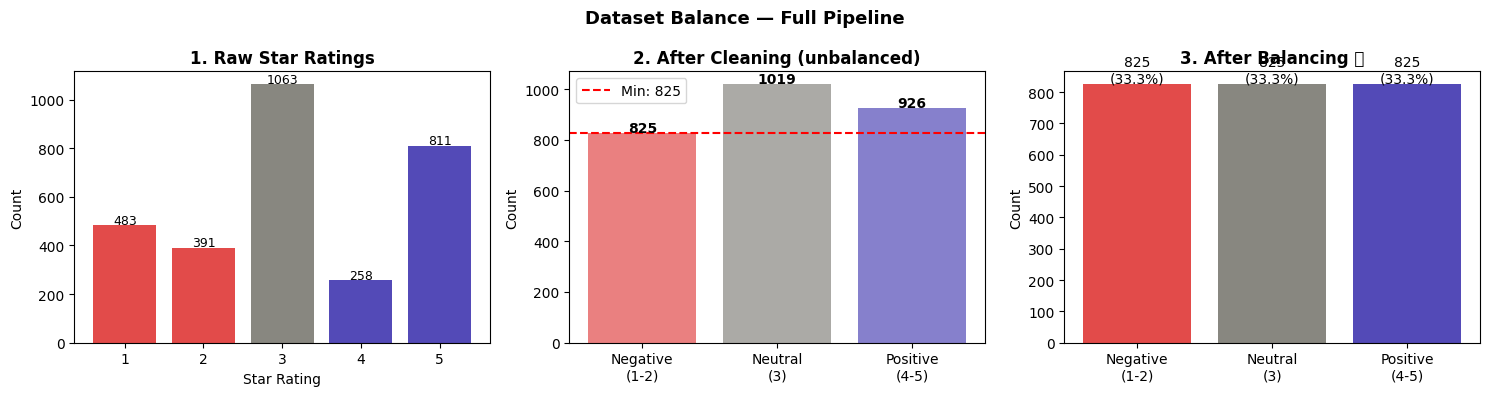

In [13]:
print('=== RAW STAR DISTRIBUTION ===')
raw_counts = df_raw['overall'].value_counts().sort_index()
print(raw_counts.to_string())
print(f'\nTotal raw: {len(df_raw)}')

# ── Step 1: Drop nulls ──
df_clean = df_raw.dropna(subset=['overall', 'reviewText']).copy()
df_clean['overall'] = df_clean['overall'].astype(int)

# ── Step 2: Clean text ──
import re
def clean_text(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['clean_text'] = df_clean['reviewText'].apply(clean_text)
df_clean['text_len']   = df_clean['clean_text'].str.len()

# ── Step 3: Remove short reviews and duplicates ──
before = len(df_clean)
df_clean = df_clean[df_clean['text_len'] >= 20]
df_clean = df_clean.drop_duplicates(subset=['clean_text']).reset_index(drop=True)
print(f'\nRemoved {before - len(df_clean)} short/duplicate reviews')

# ── Step 4: Map labels ──
def map_label(star):
    if star in [1, 2]: return 0
    elif star == 3:    return 1
    else:              return 2

df_clean['label'] = df_clean['overall'].apply(map_label)
label_names = {0: 'Negative (1-2)', 1: 'Neutral (3)', 2: 'Positive (4-5)'}

print('\n=== AFTER CLEANING — BEFORE BALANCING ===')
counts_clean = df_clean['label'].value_counts().sort_index()
for k, v in counts_clean.items():
    pct = v / len(df_clean) * 100
    bar = '█' * int(pct / 2)
    print(f'  {label_names[k]}: {v} ({pct:.1f}%) {bar}')

# ── Step 5: Balance classes ──
min_count = counts_clean.min()
min_class = label_names[counts_clean.idxmin()]

# Warn if min class is too small
if min_count < 500:
    print(f'\n⚠️  WARNING: {min_class} only has {min_count} samples')
    print(f'   Need 500+ per class for good accuracy')
    print(f'   Add {500 - min_count} more {min_class} reviews to your CSV')
else:
    print(f'\n✅ All classes have 500+ samples — good for training')

df = pd.concat([
    df_clean[df_clean['label'] == 0].sample(min_count, random_state=42),
    df_clean[df_clean['label'] == 1].sample(min_count, random_state=42),
    df_clean[df_clean['label'] == 2].sample(min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\n=== AFTER BALANCING ===')
counts_balanced = df['label'].value_counts().sort_index()
for k, v in counts_balanced.items():
    print(f'  {label_names[k]}: {v} (33.3%)')
print(f'\nFinal dataset: {len(df)} samples total')
print(f'Train (~70%):  {int(len(df)*0.7)} | per class: {int(min_count*0.7)}')

if min_count < 500:
    print(f'\n❌ Accuracy ceiling with {int(min_count*0.7)} training samples per class: ~79-80%')
    print(f'✅ Accuracy ceiling with 500+ training samples per class: ~85-88%')
else:
    print(f'\n✅ Enough data to reach 85-88% accuracy')

# ── Visual ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw
axes[0].bar([str(i) for i in raw_counts.index], raw_counts.values,
            color=['#E24B4A','#E24B4A','#888780','#534AB7','#534AB7'])
axes[0].set_title('1. Raw Star Ratings', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(raw_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=9)

# After cleaning
colors = ['#E24B4A', '#888780', '#534AB7']
axes[1].bar(['Negative\n(1-2)', 'Neutral\n(3)', 'Positive\n(4-5)'],
            counts_clean.values, color=colors, alpha=0.7)
axes[1].set_title('2. After Cleaning (unbalanced)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_clean.values):
    axes[1].text(i, v+5, f'{v}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(y=min_count, color='red', linestyle='--', linewidth=1.5,
                label=f'Min: {min_count}')
axes[1].legend()

# After balancing
axes[2].bar(['Negative\n(1-2)', 'Neutral\n(3)', 'Positive\n(4-5)'],
            counts_balanced.values, color=colors)
axes[2].set_title('3. After Balancing ✅', fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(counts_balanced.values):
    axes[2].text(i, v+5, f'{v}\n(33.3%)', ha='center', fontsize=10)

plt.suptitle('Dataset Balance — Full Pipeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
import re

def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = re.sub(r'\[\.\.\.(.*?)\]', '', text)     # remove [...] truncations
    text = re.sub(r'<[^>]+>', '', text)               # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)     # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()          # normalise whitespace
    return text

df['clean_text'] = df['reviewText'].apply(clean_text)

# Drop rows with empty text after cleaning
before = len(df)
df = df[df['clean_text'].str.len() > 3].reset_index(drop=True)
print(f'Rows before cleaning: {before}')
print(f'Rows after cleaning:  {len(df)}')
print(f'Dropped: {before - len(df)} (empty/very short reviews)')

print('\nText length stats:')
df['text_len'] = df['clean_text'].apply(len)
print(df.groupby('label')['text_len'].describe()[['mean','50%','max']].rename(
    index=label_names).round(0).to_string())

Rows before cleaning: 2475
Rows after cleaning:  2475
Dropped: 0 (empty/very short reviews)

Text length stats:
                 mean    50%     max
label                               
Negative (1-2)  226.0  153.0  2176.0
Neutral (3)     184.0   93.0  1569.0
Positive (4-5)  179.0  126.0  2631.0


In [15]:
# ── Visual check: are neutral reviews actually neutral? ──
print('=== NEUTRAL CLASS SAMPLE CHECK ===')
print('Review these carefully — mislabelled neutrals cause the most damage\n')

neutral_samples = df[df['label'] == 1].sample(15, random_state=42)
for i, row in neutral_samples.iterrows():
    text = str(row['reviewText'])[:100].replace('\n', ' ')
    print(f'[{row["overall"]}★] {text}')

print('\n=== SHORT NEUTRAL REVIEWS (most likely to be mislabelled) ===')
short_neutral = df[(df['label'] == 1) & (df['reviewText'].str.len() < 30)]
print(f'Count: {len(short_neutral)}')
for _, row in short_neutral.iterrows():
    print(f'  [{row["overall"]}★] "{row["reviewText"]}"')

=== NEUTRAL CLASS SAMPLE CHECK ===
Review these carefully — mislabelled neutrals cause the most damage

[3★] The product works for what I need but nothing special. Expected better quality at this price.
[3★] VERY CUTE but it didn't fit me. I had to consign it.
[3★] Padding moves around too much, insufficient support.
[3★] Midi skirt fits well but the lining is too short causing the outer fabric to cling.
[3★] A little to large but good leather chaps
[3★] These tights are not for people with double digit sizes or hips. After a few adjustments and limited
[3★] The royal blue doesn't look so vibrant as from the photos. I would recommend the navy or black color
[3★] The shoe covers fit my legs, but didn't cover my shoes at all. I had to adjust the Velcro on the hea
[3★] I typically wear a 2x so I ordered a 3x just to make sure it was not snug... it wouldn't even zip. I
[3★] The product is functional but the quality control seems inconsistent across items.
[3★] The only problem with these w

In [16]:
X = df['clean_text'].tolist()
y = df['label'].tolist()

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
# Second split: 50% of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f'Train:      {len(X_train)} samples')
print(f'Validation: {len(X_val)} samples')
print(f'Test:       {len(X_test)} samples')

# Verify stratification
print('\nClass distribution per split:')
for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = pd.Series(labels).value_counts().sort_index()
    pcts = (counts / len(labels) * 100).round(1)
    print(f'  {name}: Neg={pcts.get(0,0)}%  Neu={pcts.get(1,0)}%  Pos={pcts.get(2,0)}%')

Train:      1732 samples
Validation: 371 samples
Test:       372 samples

Class distribution per split:
  Train: Neg=33.4%  Neu=33.3%  Pos=33.3%
  Val: Neg=33.2%  Neu=33.4%  Pos=33.4%
  Test: Neg=33.3%  Neu=33.3%  Pos=33.3%


In [17]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 256   # 256 covers ~95% of reviews without truncation

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Loaded tokenizer: {MODEL_NAME}')

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

# Build HuggingFace Datasets
train_ds = Dataset.from_dict({'text': X_train, 'labels': y_train})
val_ds   = Dataset.from_dict({'text': X_val,   'labels': y_val})
test_ds  = Dataset.from_dict({'text': X_test,  'labels': y_test})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type='torch', columns=cols)
val_ds.set_format(type='torch', columns=cols)
test_ds.set_format(type='torch', columns=cols)

print(f'\nTrain tokens shape: {train_ds[0]["input_ids"].shape}')
print(f'Tokenization complete: {len(train_ds)} train | {len(val_ds)} val | {len(test_ds)} test')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded tokenizer: distilbert-base-uncased


Map:   0%|          | 0/1732 [00:00<?, ? examples/s]

Map:   0%|          | 0/371 [00:00<?, ? examples/s]

Map:   0%|          | 0/372 [00:00<?, ? examples/s]


Train tokens shape: torch.Size([256])
Tokenization complete: 1732 train | 371 val | 372 test


In [18]:
id2label = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)

print(f'Model loaded on: {device}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print('Note: No class weights — dataset is balanced at 33.3% each, weights not needed')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda
Trainable params: 66,955,779
Note: No class weights — dataset is balanced at 33.3% each, weights not needed


In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=1)
    acc      = accuracy_score(labels, preds)
    f1       = f1_score(labels, preds, average='weighted')
    f1_macro = f1_score(labels, preds, average='macro')
    f1_per   = f1_score(labels, preds, average=None)
    prec     = precision_score(labels, preds, average='weighted', zero_division=0)
    rec      = recall_score(labels, preds, average='weighted', zero_division=0)
    return {
        'accuracy':    round(acc,       4),
        'f1':          round(f1,        4),
        'f1_macro':    round(f1_macro,  4),
        'f1_negative': round(f1_per[0], 4),
        'f1_neutral':  round(f1_per[1], 4),
        'f1_positive': round(f1_per[2], 4),
        'precision':   round(prec,      4),
        'recall':      round(rec,       4),
    }

print('Standard Trainer metrics ready.')

Standard Trainer metrics ready.


In [20]:
training_args = TrainingArguments(
    output_dir                  = './distilbert_final',
    num_train_epochs            = 6,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    lr_scheduler_type           = 'linear',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = 'none',
    fp16                        = (device == 'cuda'),
    save_total_limit            = 2,
)
print(f'LR: {training_args.learning_rate} | Label smoothing: 0.1')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


LR: 2e-05 | Label smoothing: 0.1


In [21]:
trainer = Trainer(                               # ← back to standard Trainer
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)]
)

print('Starting training...')
train_result = trainer.train()

print(f'\n=== TRAINING COMPLETE ===')
print(f'Total time:  {train_result.metrics["train_runtime"]:.1f}s')
print(f'Final loss:  {train_result.metrics["train_loss"]:.4f}')

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro,F1 Negative,F1 Neutral,F1 Positive,Precision,Recall
1,0.892184,0.648854,0.733200,0.727500,0.727500,0.726500,0.645700,0.810200,0.732300,0.733200
2,0.509309,0.555408,0.762800,0.759400,0.759400,0.755400,0.657500,0.865300,0.770700,0.762800
3,0.343358,0.607282,0.768200,0.769800,0.769700,0.737700,0.713200,0.858300,0.772800,0.768200
4,0.223250,0.676370,0.770900,0.771700,0.771600,0.733900,0.712000,0.868900,0.772700,0.770900
5,0.129937,0.777117,0.773600,0.773900,0.773700,0.717900,0.725200,0.878000,0.776900,0.773600
6,0.086405,0.802491,0.773600,0.773800,0.773700,0.723400,0.723100,0.874500,0.776100,0.773600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



=== TRAINING COMPLETE ===
Total time:  114.9s
Final loss:  0.3780


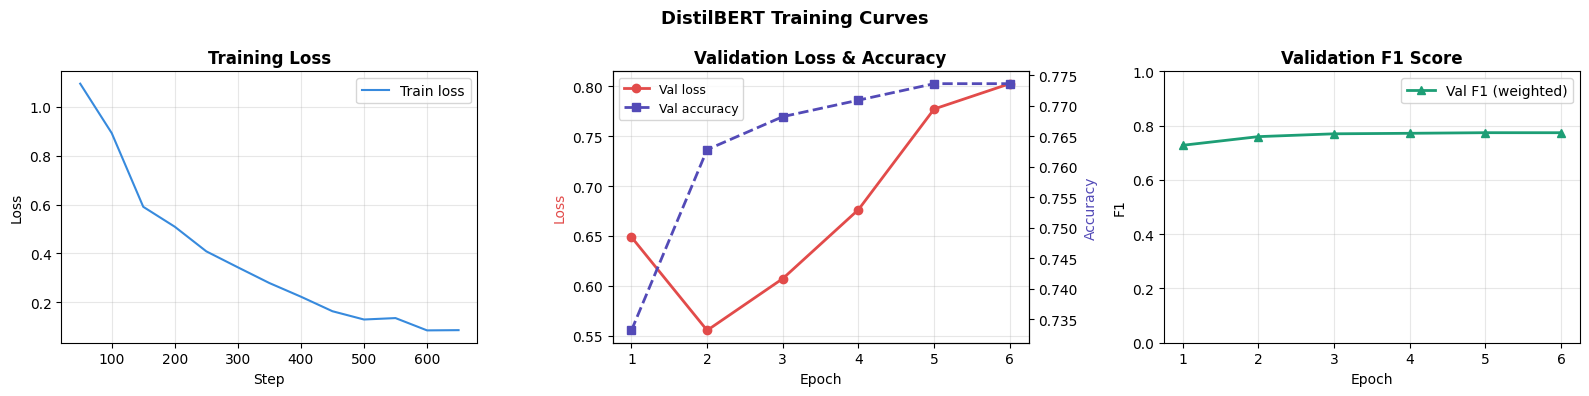


Best validation accuracy: 0.7736 at epoch 5.0


In [22]:
# Extract log history
log_history = trainer.state.log_history

train_steps  = [x['step']  for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss']  for x in log_history if 'loss' in x and 'eval_loss' not in x]

eval_epochs   = [x['epoch']     for x in log_history if 'eval_loss' in x]
eval_losses   = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_accs     = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]
eval_f1s      = [x['eval_f1']   for x in log_history if 'eval_f1' in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training loss
axes[0].plot(train_steps, train_losses, color='#378ADD', linewidth=1.5, label='Train loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Eval loss vs accuracy
ax2b = axes[1].twinx()
axes[1].plot(eval_epochs, eval_losses, color='#E24B4A', linewidth=2, marker='o', label='Val loss')
ax2b.plot(eval_epochs, eval_accs,   color='#534AB7', linewidth=2, marker='s', linestyle='--', label='Val accuracy')
axes[1].set_title('Validation Loss & Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss', color='#E24B4A')
ax2b.set_ylabel('Accuracy', color='#534AB7')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)
axes[1].grid(alpha=0.3)

# F1 per epoch
axes[2].plot(eval_epochs, eval_f1s, color='#1D9E75', linewidth=2, marker='^', label='Val F1 (weighted)')
axes[2].set_title('Validation F1 Score', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle('DistilBERT Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_epoch = eval_epochs[np.argmax(eval_accs)]
best_acc   = max(eval_accs)
print(f'\nBest validation accuracy: {best_acc:.4f} at epoch {best_epoch}')

In [23]:
print('=== VALIDATION SET EVALUATION ===')
val_results = trainer.evaluate(val_ds)

print(f'  Accuracy:  {val_results["eval_accuracy"]:.4f} ({val_results["eval_accuracy"]*100:.2f}%)')
print(f'  F1:        {val_results["eval_f1"]:.4f}')
print(f'  Precision: {val_results["eval_precision"]:.4f}')
print(f'  Recall:    {val_results["eval_recall"]:.4f}')
print(f'  Loss:      {val_results["eval_loss"]:.4f}')

=== VALIDATION SET EVALUATION ===


  Accuracy:  0.7736 (77.36%)
  F1:        0.7739
  Precision: 0.7769
  Recall:    0.7736
  Loss:      0.7770


In [24]:
print('=== TEST SET EVALUATION (FINAL) ===')

# Get raw predictions
test_output = trainer.predict(test_ds)
logits_test  = test_output.predictions
labels_test  = test_output.label_ids
preds_test   = np.argmax(logits_test, axis=1)

test_acc  = accuracy_score(labels_test, preds_test)
test_f1   = f1_score(labels_test, preds_test, average='weighted')
test_prec = precision_score(labels_test, preds_test, average='weighted', zero_division=0)
test_rec  = recall_score(labels_test, preds_test, average='weighted', zero_division=0)

print(f'  Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  F1:        {test_f1:.4f}')
print(f'  Precision: {test_prec:.4f}')
print(f'  Recall:    {test_rec:.4f}')

=== TEST SET EVALUATION (FINAL) ===


  Accuracy:  0.7554 (75.54%)
  F1:        0.7575
  Precision: 0.7620
  Recall:    0.7554


In [25]:
target_names = ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)']

print('=== DETAILED CLASSIFICATION REPORT (TEST SET) ===')
print()
report = classification_report(
    labels_test, preds_test,
    target_names=target_names,
    digits=4
)
print(report)

# Save report to file
with open('classification_report.txt', 'w') as f:
    f.write('DistilBERT Sentiment Classification — Test Set Report\n')
    f.write('='*55 + '\n')
    f.write(f'Accuracy:  {test_acc:.4f}\n')
    f.write(f'F1:        {test_f1:.4f}\n')
    f.write(f'Precision: {test_prec:.4f}\n')
    f.write(f'Recall:    {test_rec:.4f}\n\n')
    f.write(report)
print('Report saved to classification_report.txt')

=== DETAILED CLASSIFICATION REPORT (TEST SET) ===

                precision    recall  f1-score   support

Negative (1-2)     0.7458    0.7097    0.7273       124
   Neutral (3)     0.6522    0.7258    0.6870       124
Positive (4-5)     0.8879    0.8306    0.8583       124

      accuracy                         0.7554       372
     macro avg     0.7620    0.7554    0.7575       372
  weighted avg     0.7620    0.7554    0.7575       372

Report saved to classification_report.txt
